#Installierung von pandas und aufladung von Dataset

In [25]:
import pandas as pd 

daten = pd.read_csv("immo_data.csv", low_memory=False)

aber wir wollen nur die Stadt von München beobachten

In [26]:
daten_münchen = daten[daten["regio2"] == "München"]


wir zeigen die Größe des Dataset und die 5 erste zeile

In [27]:
print(f"anzahl der Anzeigen in München sind:", {daten_münchen.shape[0]})
display(daten_münchen)

anzahl der Anzeigen in München sind: {4383}


,regio1,serviceCharge,heatingType,telekomTvOffer,telekomHybridUploadSpeed,newlyConst,balcony,picturecount,pricetrend,telekomUploadSpeed,...,regio2,regio3,description,facilities,heatingCosts,energyEfficiencyClass,lastRefurbish,electricityBasePrice,electricityKwhPrice,date
23,Bayern,180.0,central_heating,ONE_YEAR_FREE,NaN,False,False,18,4.47,10.0,...,München,Altstadt,Die Wohnung (OHNE Balkon !!) liegt im 4. OG (O...,- Eichenparkettboden im Wohn-EZ u. im Schlafzi...,NaN,NO_INFORMATION,NaN,NaN,NaN,Oct19
28,Bayern,0.0,NaN,ONE_YEAR_FREE,NaN,False,True,25,7.53,40.0,...,München,Schwabing_West,"Highlights:\n\n * alle Wände der Wohnräume, Kü...",Waschmaschine in der Wohnung\nFlachbildfernseh...,NaN,NaN,NaN,NaN,NaN,May19
32,Bayern,0.0,NaN,ONE_YEAR_FREE,NaN,False,True,29,6.08,40.0,...,München,Milbertshofen,Bitte beachten Sie: Die Wohnung ist komplett m...,Waschmaschine in der Wohnung\nFlachbildfernseh...,NaN,NaN,NaN,NaN,NaN,Feb20
118,Bayern,NaN,NaN,NaN,NaN,True,True,14,7.32,NaN,...,München,Schwabing,Möbliertes Wohnen auf Zeit:\nModernes Apartmen...,Bettwäsche\nCouch\nDusche\nEinbauküche\nFranzö...,NaN,C,NaN,NaN,NaN,May19
161,Bayern,290.0,district_heating,ONE_YEAR_FREE,NaN,False,True,16,5.72,10.0,...,München,Ludwigsvorstadt_Isarvorstadt,"Das Mehrfamilienhaus ""COR 4"" (60er Jahre Kult)...",Eichenparkett m. weißen Sockelleisten\nFußbode...,NaN,NO_INFORMATION,2019.0,NaN,NaN,Oct19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268688,Bayern,320.0,oil_heating,ONE_YEAR_FREE,NaN,False,True,24,4.88,10.0,...,München,Obermenzing,"Die traumhaft gelegene, 2019/2020 komplett san...","Echtholz-Eichendielenparkett: Wohnzimmer, Schl...",NaN,D,2020.0,NaN,NaN,Feb20
268712,Bayern,165.0,district_heating,ONE_YEAR_FREE,NaN,False,True,11,5.88,40.0,...,München,Ramersdorf,Gepflegte Wohnanlage mit Spielplätzen und groß...,* die Wohnräume sind mit neuem Parkett ausgest...,160.0,NaN,2019.0,NaN,NaN,Oct19
268752,Bayern,0.0,central_heating,ONE_YEAR_FREE,10.0,False,True,32,7.44,2.4,...,München,Milbertshofen,"Dieses komplett sanierte, möblierte und voll a...",Große helle Fliesen in Küche und Bad (weiss u....,NaN,NaN,2019.0,NaN,NaN,May19
268818,Bayern,180.0,central_heating,ONE_YEAR_FREE,NaN,False,True,9,6.96,40.0,...,München,Bogenhausen,Die frisch sanierte Wohnung begrüßt Sie mit ei...,- Kellerabteil\n- Bad mit Badewanne und WC\n- ...,175.0,NaN,2019.0,NaN,NaN,May19


versuchen wir wichtige Spalte zu suchen


In [28]:
nötige_spalte = [
    "baseRent",     # unsere Target, was wir vorhersagen wollen
    "livingSpace",  # Fläche in m²
    "noRooms",      # Anzahl der Zimmern
    "condition",    # Zustand/Status der Wohnung
    "yearConstructed",  # Baujahr
    "balcony"        # gibt es balkon oder nicht
]


daten_münchen_bereinigt = daten_münchen[nötige_spalte].copy()

Danach müssen wir die Nan-Spalte gucken und sie zählen

In [29]:
display(daten_münchen_bereinigt.isnull().sum())


baseRent              0
livingSpace           0
noRooms               0
condition          1206
yearConstructed     751
balcony               0
dtype: int64

Aktuell will ich gerne die Nan löschen

In [30]:
daten_münchen_bereinigt = daten_münchen_bereinigt.dropna()


EDA: Explorative Daten analyse

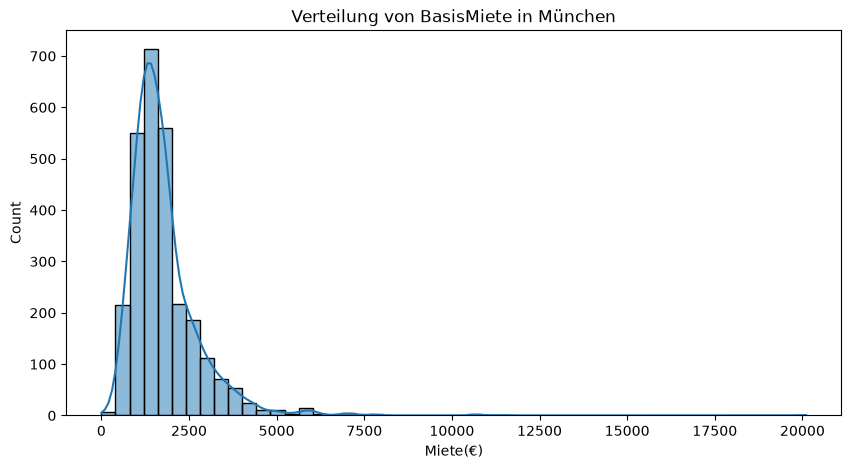

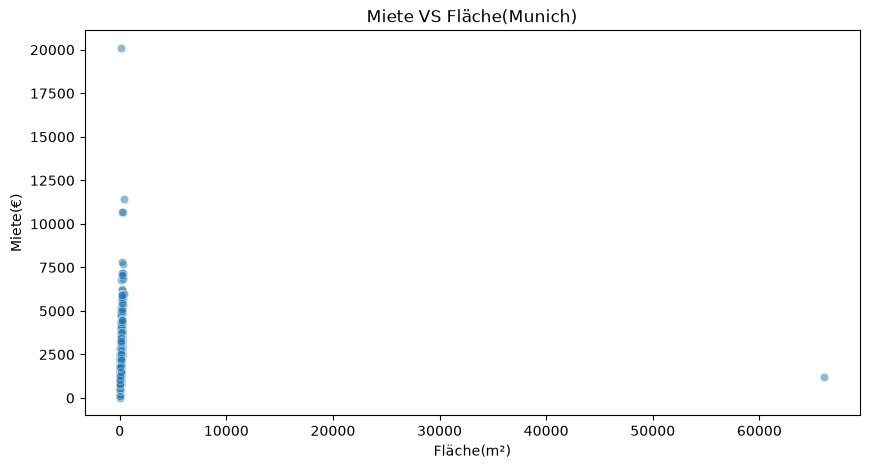

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns



# Graphik1 : Verteilung von Miete in München

plt.figure(figsize=(10,5))
sns.histplot(daten_münchen_bereinigt["baseRent"], bins=50, kde=True)
plt.title("Verteilung von BasisMiete in München")
plt.xlabel("Miete(€)")
plt.show()

# Graphik1 : Verteilung von Miete in München
plt.figure(figsize=(10,5))
sns.scatterplot(data=daten_münchen_bereinigt, x="livingSpace", y="baseRent", alpha=0.5)
plt.title("Miete VS Fläche(Munich)")
plt.xlabel("Fläche(m²)")
plt.ylabel("Miete(€)")
plt.show()

Achso ich habe meine Grafike analysieren und ich habe gemerkt. dass es einige Ausreißer gibt. Die idee ist doch die verhältnis Miete/Fläche realistisch zu machen

Dafür habe ich eine Intervall ausgewählt, die Basismiete müssen zwischen 300 und 5000 bleiben aber Fläche der Häuser zwischen 15 und 300

In [32]:
daten_münchen_bereinigt = daten_münchen_bereinigt[
    (daten_münchen_bereinigt['baseRent'] >= 300) & (daten_münchen_bereinigt['baseRent'] <= 5000) &
    (daten_münchen_bereinigt['livingSpace'] >= 15) & (daten_münchen_bereinigt['livingSpace'] <= 300)
]

suchen wir, wie viele Daten es noch gibt?

In [33]:
print(f"Anzahl der Anzeige nach der bereinigung: {daten_münchen_bereinigt.shape[0]}")

Anzahl der Anzeige nach der bereinigung: 2721


Natürlich ein neue Graphik soll ich erstellen:

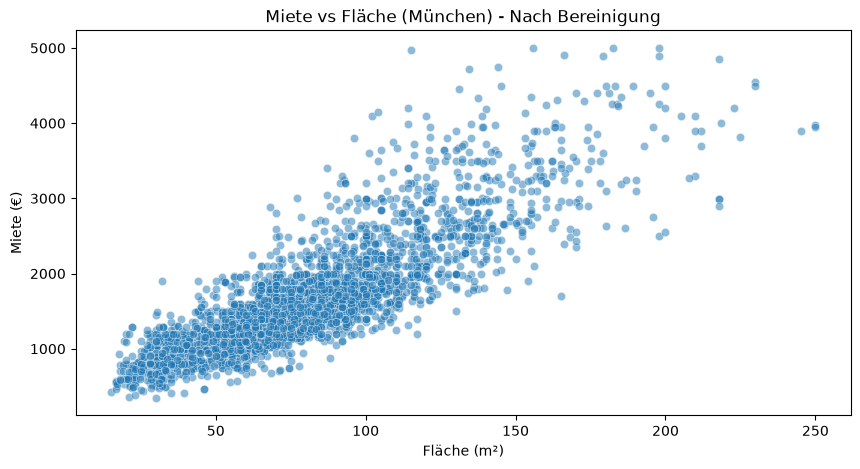

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.scatterplot(data=daten_münchen_bereinigt, x='livingSpace', y='baseRent', alpha=0.5)
plt.title("Miete vs Fläche (München) - Nach Bereinigung")
plt.xlabel("Fläche (m²)")
plt.ylabel("Miete (€)")
plt.show()